# 00 · Start Here — Setup, Environment & Dataset Tour 🔴

> 📖 **Website:** [4-Hour Study Plan](http://localhost:5173/#study-plan) · Orientation · 10 min

Welcome to the companion notebook suite for **Machine Learning Fundamentals — 4-Hour AI Engineer Interview Review**.

The website teaches intuition, formulas, comparison tables, interview answers, and common mistakes. **These notebooks do what a static page cannot: run the empirical experiments, decompose errors, break assumptions on purpose, and show the exact numbers.**

---

### 🌐 Pairing With the Website

The website is a fast Vite single-page application. While working through these notebooks, you can keep the website open on one screen and run the experiments on the other.
* To launch the website locally: run `npm run dev` from the repository root, then open `http://localhost:5173/`.
* Every major section in these notebooks contains a direct link back to its corresponding website topic.
* All notebooks are fully self-contained and run completely offline without internet or running the website.

---

### 🗺️ The 4-Hour Study Roadmap

| Notebook | Hour | Primary Focus | Key Experiments |
| :--- | :--- | :--- | :--- |
| **[`01_core_concepts.ipynb`](01_core_concepts.ipynb)** | Hour 1 | Core Foundations | Group/Temporal splits, 6 Data Leakage experiments, Empirical Bias-Variance decomposition, Nested CV |
| **[`02_metrics_and_data.ipynb`](02_metrics_and_data.ipynb)** | Hour 2 | Metrics & Data Prep | Confusion matrix from scratch, Cost-sensitive threshold tuning, ROC vs PR-AUC under severe imbalance, Calibration, Outliers |
| **[`03_models_and_training.ipynb`](03_models_and_training.ipynb)** | Hour 3 | Models & Training | Gradient Descent from scratch (4 regimes), Logistic regression from scratch, L1/L2 paths, 8-model bake-off & RF tree correlation |
| **[`04_review_and_practice.ipynb`](04_review_and_practice.ipynb)** | Hour 4 | Review & Practice | Accuracy/Latency Pareto frontier, PCA with/without scaling, K-Means from scratch, 11-step Capstone Pipeline, 8 Debugging Drills, Readiness Assessment |


### 0.1 Environment Verification 🔴

**The question:** Are all required core libraries present with compatible versions so that no experiment fails midway through Hour 3?

**What you'll see:** A clear table checking Python, NumPy, Pandas, Matplotlib, and Scikit-Learn versions with confirmation indicators.

In [1]:
import sys
import importlib
from packaging.version import Version

CORE_REQUIREMENTS = {
    "numpy": "1.26.0",
    "pandas": "2.1.0",
    "matplotlib": "3.8.0",
    "sklearn": "1.4.0",
}

print(f"Python Version: {sys.version.split()[0]}")
assert sys.version_info >= (3, 9), "Python 3.9+ is required."

all_passed = True
for pkg, min_ver in CORE_REQUIREMENTS.items():
    try:
        mod = importlib.import_module(pkg)
        ver = getattr(mod, "__version__", "unknown")
        if Version(ver) < Version(min_ver):
            print(f"❌ {pkg:<12} {ver:<10} is too old; run: pip install '{pkg}>={min_ver}'")
            all_passed = False
        else:
            print(f"✅ {pkg:<12} {ver:<10} (minimum: {min_ver})")
    except ImportError:
        print(f"❌ {pkg:<12} NOT INSTALLED (required: pip install {pkg}>={min_ver})")
        all_passed = False

assert all_passed, "Install or upgrade the failed core dependencies, then restart the kernel."
print("\nAll core dependencies are satisfied and ready for execution.")


Python Version: 3.11.14
✅ numpy        2.4.6      (minimum: 1.26.0)


✅ pandas       3.0.5      (minimum: 2.1.0)
✅ matplotlib   3.11.1     (minimum: 3.8.0)


✅ sklearn      1.9.0      (minimum: 1.4.0)

All core dependencies are satisfied and ready for execution.


> 🎤 **In an interview:** "I always establish an explicit environment baseline and deterministic seeds before running benchmarks, ensuring experiment reproducibility across team members." 

### 0.2 Optional Dependencies Check 🟠

**The question:** Are optional acceleration libraries (`lightgbm`, `xgboost`, `imbalanced-learn`, `optuna`, `ipywidgets`) available?

**What you'll see:** Status of optional packages, with confirmation that graceful fallbacks are enabled if any are absent.

In [2]:
OPTIONAL_PACKAGES = ["imblearn", "lightgbm", "xgboost", "optuna", "ipywidgets"]

print("Checking optional packages (notebooks degrade gracefully if missing):\n")
for pkg in OPTIONAL_PACKAGES:
    try:
        mod = importlib.import_module(pkg)
        ver = getattr(mod, "__version__", "installed")
        print(f"✅ Optional: {pkg:<16} {ver}")
    except ImportError:
        print(f"ℹ️ Optional: {pkg:<16} not found (using standard scikit-learn fallbacks)")


Checking optional packages (notebooks degrade gracefully if missing):



✅ Optional: imblearn         0.14.2
✅ Optional: lightgbm         4.7.0
✅ Optional: xgboost          3.2.0
✅ Optional: optuna           4.9.0
✅ Optional: ipywidgets       8.1.9


> 🎤 **In an interview:** "I separate required dependencies from optional accelerators. The core pipeline must remain reproducible even when a native boosting library is unavailable." 

### 0.3 Synthetic Churn Panel Tour 🔴
> 📖 **Website:** [Data Leakage](http://localhost:5173/#data-leakage)

**The question:** What does our recurring synthetic dataset look like, and what specific ML traps are planted inside it?

**What you'll see:** A preview of `make_churn_panel()`, including its shape, columns, missingness pattern, class imbalance, and a guided breakdown of each planted property.

Dataset Shape: 12,000 rows × 11 columns
Unique Users  : 4,000
Snapshots     : ['2025-01-01', '2025-02-01', '2025-03-01']
Churn Rate    : 6.37% (severe class imbalance)
Missing Income: 11.21% (MNAR missingness)

Column dtypes:
user_id                                str
snapshot_date               datetime64[us]
tenure_days                        float64
monthly_spend                      float64
logins_30d                           int64
income                             float64
plan_region                            str
device                                 str
support_tickets_30d                  int64
cancellation_reason_code               str
churned                              int64


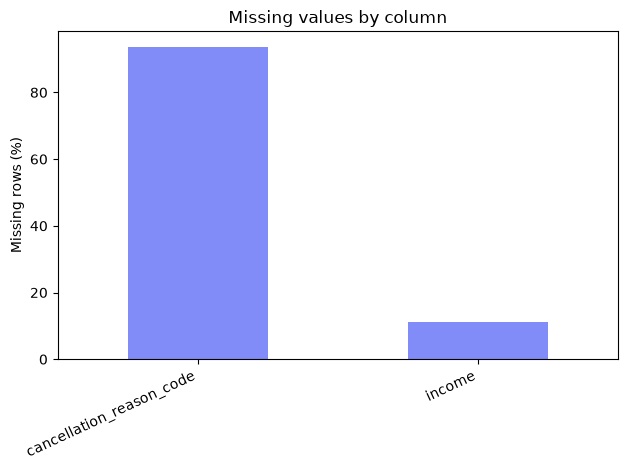

,user_id,snapshot_date,tenure_days,monthly_spend,logins_30d,income,plan_region,device,support_tickets_30d,cancellation_reason_code,churned
0,USR_0001,2025-01-01,235.9,79.33,50,48300.0,REG_119,iOS,0,NaN,0
1,USR_0002,2025-01-01,182.1,52.07,45,NaN,REG_106,Android,0,NaN,0
2,USR_0003,2025-01-01,332.8,73.85,56,53000.0,REG_155,Web,0,NaN,0
3,USR_0004,2025-01-01,632.2,152.00,50,75100.0,REG_194,iOS,0,NaN,0
4,USR_0005,2025-01-01,493.2,51.64,44,124300.0,REG_185,Android,0,NaN,0
5,USR_0006,2025-01-01,464.8,55.13,55,52500.0,REG_198,iOS,0,NaN,0


In [3]:
from mlprep.data import make_churn_panel
import matplotlib.pyplot as plt

# Generate the recurring churn panel (4,000 users across 3 monthly snapshots = 12,000 rows)
df_churn = make_churn_panel(n_users=4000, snapshots_per_user=3, seed=7)

print(f"Dataset Shape: {df_churn.shape[0]:,} rows × {df_churn.shape[1]} columns")
print(f"Unique Users  : {df_churn['user_id'].nunique():,}")
print(f"Snapshots     : {df_churn['snapshot_date'].dt.strftime('%Y-%m-%d').unique().tolist()}")
print(f"Churn Rate    : {df_churn['churned'].mean():.2%} (severe class imbalance)")
print(f"Missing Income: {df_churn['income'].isna().mean():.2%} (MNAR missingness)")
print("\nColumn dtypes:")
print(df_churn.dtypes.to_string())

missing_pct = (100 * df_churn.isna().mean()).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]
missing_pct.plot.bar(color="#818cf8", title="Missing values by column")
plt.ylabel("Missing rows (%)")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

display_cols = ["user_id", "snapshot_date", "tenure_days", "monthly_spend", "logins_30d", "income", "plan_region", "device", "support_tickets_30d", "cancellation_reason_code", "churned"]
df_churn[display_cols].head(6)


#### 🔎 Planted Properties in the Churn Panel:

| Column | Planted Mechanism & Educational Purpose |
| :--- | :--- |
| `user_id` | Repeated records per user across monthly snapshots $\rightarrow$ Demonstrates **group leakage** and the necessity of `GroupKFold`. |
| `snapshot_date` | Monotone chronological timestamp $\rightarrow$ Demonstrates **temporal leakage** and forward-chaining validation (`TimeSeriesSplit`). |
| `tenure_days`, `monthly_spend`, `logins_30d` | Wildly disparate scales ($10\text{--}2000$, $\$15\text{--}350$, $0\text{--}100$) $\rightarrow$ Demonstrates **feature scaling** necessity for distance/linear models and invariance in trees. |
| `income` | Missing Not At Random (**MNAR**) missingness (missing at $>50\%$ rate for high earners) $\rightarrow$ Demonstrates when a **missing indicator** can retain information. |
| `plan_region` | High cardinality ($\sim 200$ levels) $\rightarrow$ Demonstrates **one-hot explosion vs out-of-fold target encoding**. |
| `device` | 4 unordered categories (`iOS`, `Android`, `Web`, `Desktop`) $\rightarrow$ Demonstrates the **ordinal encoding false-order trap**. |
| `support_tickets_30d` | Features collected over a window straddling the churn label $\rightarrow$ Demonstrates **temporal leakage**. |
| `cancellation_reason_code` | Only populated for churned customers $\rightarrow$ Demonstrates **target leakage** and drop-feature ablation diagnostics. |
| `churned` | $\sim 6\%$ positive baseline prevalence $\rightarrow$ Demonstrates **ROC-AUC vs PR-AUC divergence**, cost-sensitive thresholds, and resampling methods. |


> 🎤 **In an interview:** "Before training any model, I run an exploratory audit on entity identifiers, timestamp monotonicity, and target-conditional missingness to catch leakage before it reaches cross-validation." 

### 0.4 How to Use These Notebooks

1. **Run All Top-to-Bottom**: At the beginning of each hour, run the notebook top-to-bottom to confirm the baseline.
2. **Attempt the Exercises**: Try solving the exercises in the `# YOUR CODE HERE` blocks before expanding the collapsible `💡 Solution` dropdowns.
3. **Say the 🎤 Interview Lines Out Loud**: The interview callout at the end of each cell summarizes the exact phrasing Senior and Staff ML engineers use in technical interviews.

Ready to begin? Move to **[`01_core_concepts.ipynb`](01_core_concepts.ipynb)**!